<a href="https://colab.research.google.com/github/mbowen36-lab/ECGR-4105/blob/main/Homework%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECGR-4105: Homework 2
Name: Matthew Bowen\
Student ID: 801345379

In [1049]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
from IPython.display import display
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1050]:
file_path = '/content/drive/My Drive/ECGR 4105/Datasets/Housing.csv'
df = pd.read_csv(file_path)
print(df.head())

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [1051]:
y  = df.values[:, 0].astype('float64')    #price

In [1052]:
idx = np.random.permutation(len(y))
split = int(0.8 * len(y))
train_idx, val_idx = idx[:split], idx[split:]

In [1053]:
X1 = df.values[:, 1].astype('float64')    #area
X2 = df.values[:, 2].astype('float64')    #bedrooms
X3 = df.values[:, 3].astype('float64')    #bathrooms
X4 = df.values[:, 4].astype('float64')    #stories
X10 = df.values[:, 10].astype('float64')  #parking

In [1054]:
X5 = (df.values[:, 5] == "yes").astype('float64')    #mainroad
X6 = (df.values[:, 6] == "yes").astype('float64')    #guestroom
X7 = (df.values[:, 7] == "yes").astype('float64')    #basement
X8 = (df.values[:, 8] == "yes").astype('float64')    #hotwaterheating
X9 = (df.values[:, 9] == "yes").astype('float64')    #airconditioning
X11 = (df.values[:, 11] == "yes").astype('float64')  #prefarea

In [1055]:
mapping = {"furnished": 1.0, "semi-furnished": 0.5, "unfurnished": 0.0}
vectorized_mapping = np.vectorize(mapping.get)

X12 = vectorized_mapping(df.values[:, 12]).astype('float64')  #furnishingstatus

In [1056]:
y_train, y_val = y[train_idx], y[val_idx]

m = len(y_train)
n = len(y_val)

X1_train, X1_val = X1[train_idx], X1[val_idx]
X2_train, X2_val = X2[train_idx], X2[val_idx]
X3_train, X3_val = X3[train_idx], X3[val_idx]
X4_train, X4_val = X4[train_idx], X4[val_idx]
X5_train, X5_val = X5[train_idx], X5[val_idx]
X6_train, X6_val = X6[train_idx], X6[val_idx]
X7_train, X7_val = X7[train_idx], X7[val_idx]
X8_train, X8_val = X8[train_idx], X8[val_idx]
X9_train, X9_val = X9[train_idx], X9[val_idx]
X10_train, X10_val = X10[train_idx], X10[val_idx]
X11_train, X11_val = X11[train_idx], X11[val_idx]
X12_train, X12_val = X12[train_idx], X12[val_idx]

In [1057]:
X_0_train = np.ones((m,1))
X_0_val = np.ones((n,1))

names = [
    'area',
    'bedrooms',
    'bathrooms',
    'stories',
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'parking',
    'prefarea',
    'furnishingstatus'
]

X_raw_train = [
    X1_train,
    X2_train,
    X3_train,
    X4_train,
    X5_train,
    X6_train,
    X7_train,
    X8_train,
    X9_train,
    X10_train,
    X11_train,
    X12_train
]

X_raw_val = [
    X1_val,
    X2_val,
    X3_val,
    X4_val,
    X5_val,
    X6_val,
    X7_val,
    X8_val,
    X9_val,
    X10_val,
    X11_val,
    X12_val
]

X_n_train = {name: x.reshape(m, 1) for name, x in zip(names, X_raw_train)}
X_n_val   = {name: x.reshape(n, 1) for name, x in zip(names, X_raw_val)}

In [1058]:
def compute_cost(X, y, theta, lambda_=0.):

  m = len(y)

  errors = X.dot(theta) - y
  J = 1 / (2 * m) * np.sum(errors ** 2)

  return J

In [1059]:
def gradient_descent(X_train, y_train, X_val, y_val, theta, alpha, iterations):

  m = len(y_train)
  training_costs = np.zeros(iterations)
  validation_costs = np.zeros(iterations)

  for i in range(iterations):
    errors = X_train.dot(theta) - y_train
    sum_delta = (alpha / m) * X_train.transpose().dot(errors)
    theta = theta - sum_delta
    training_costs[i] = compute_cost(X_train, y_train, theta)
    validation_costs[i] = compute_cost(X_val, y_val, theta)

  return theta, training_costs, validation_costs

In [1060]:
def convergence_plot(training_costs, validation_costs):

  plt.plot(range(1, iterations + 1), training_costs, color='red', label='Training Loss')
  plt.plot(range(1, iterations + 1), validation_costs, color='blue', label='Validation Loss')
  plt.rcParams["figure.figsize"] = (10, 6)
  plt.grid(True)

  plt.legend(loc='upper right')
  plt.ylim(0, 2000000000000)
  plt.xlabel('Number of iterations')
  plt.ylabel('Cost (J)')
  plt.title('Convergence of gradient descent')

  plt.show()

In [1061]:
iterations = 1500

theta = [ 29.19917099 840.91299681 112.94275103  61.09899426  99.41633628
  22.6258941 ]
training loss history = [5.65717715e+12 3.10566742e+12 2.21778960e+12 ... 1.74356459e+12
 1.74356434e+12 1.74356410e+12]
validation loss history = [3.83309399e+12 3.31925162e+12 1.44347117e+12 ... 1.40781607e+12
 1.40781593e+12 1.40781578e+12]


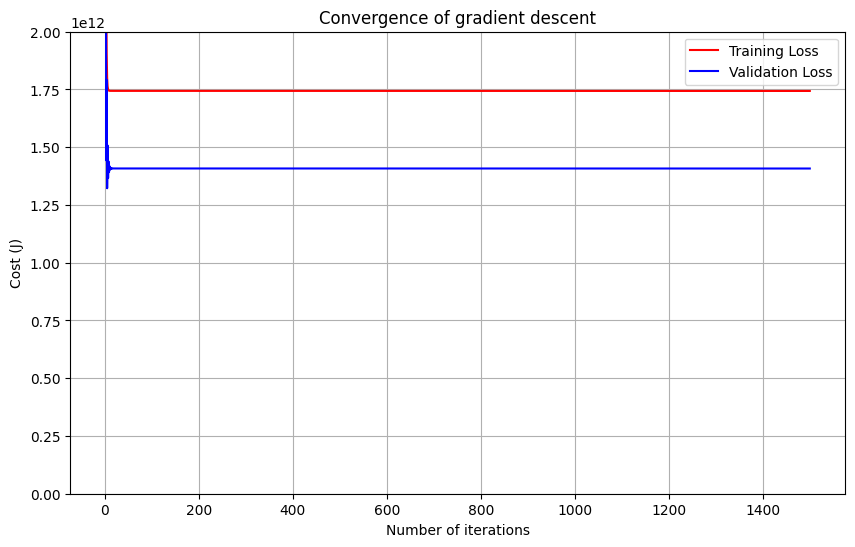

In [1062]:
# Area, bedrooms, bathrooms, stories, parking - No scaling
alpha = 0.00000005

theta = (np.zeros(6))
X_train = np.hstack((
    X_0_train,
    X_n_train['area'],
    X_n_train['bedrooms'],
    X_n_train['bathrooms'],
    X_n_train['stories'],
    X_n_train['parking']
))
X_val = np.hstack((
    X_0_val,
    X_n_val['area'],
    X_n_val['bedrooms'],
    X_n_val['bathrooms'],
    X_n_val['stories'],
    X_n_val['parking']
))

theta, training_costs, validation_costs = gradient_descent(X_train, y_train, X_val, y_val, theta, alpha, iterations)
print('theta =', theta)
print('training loss history =', training_costs)
print('validation loss history =', validation_costs)

convergence_plot(training_costs, validation_costs)

theta = [ 29.19903259 840.90582481 112.94228182  61.09878324  99.4160129
  24.9236727   11.57738706  20.89438402   3.93944376  24.2020538
  22.62583093  11.69524378]
training loss history = [5.65717774e+12 3.10566777e+12 2.21778971e+12 ... 1.74353897e+12
 1.74353871e+12 1.74353845e+12]
validation loss history = [3.83309451e+12 3.31925204e+12 1.44347121e+12 ... 1.40779573e+12
 1.40779557e+12 1.40779542e+12]


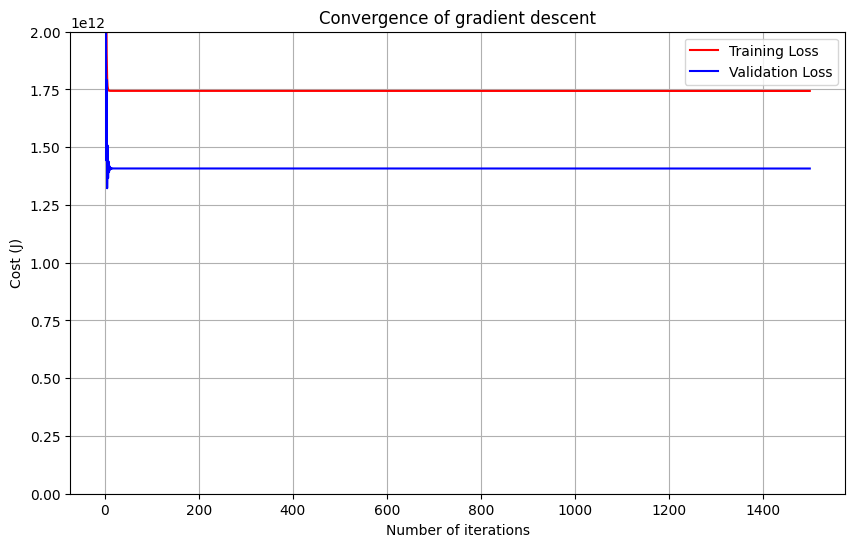

In [1063]:
# All except furnishing - No scaling
alpha = 0.00000005

theta = (np.zeros(12))
X_train = np.hstack((
    X_0_train,
    X_n_train['area'],
    X_n_train['bedrooms'],
    X_n_train['bathrooms'],
    X_n_train['stories'],
    X_n_train['mainroad'],
    X_n_train['guestroom'],
    X_n_train['basement'],
    X_n_train['hotwaterheating'],
    X_n_train['airconditioning'],
    X_n_train['parking'],
    X_n_train['prefarea']
))
X_val = np.hstack((
    X_0_val,
    X_n_val['area'],
    X_n_val['bedrooms'],
    X_n_val['bathrooms'],
    X_n_val['stories'],
    X_n_val['mainroad'],
    X_n_val['guestroom'],
    X_n_val['basement'],
    X_n_val['hotwaterheating'],
    X_n_val['airconditioning'],
    X_n_val['parking'],
    X_n_val['prefarea']
))

theta, training_costs, validation_costs = gradient_descent(X_train, y_train, X_val, y_val, theta, alpha, iterations)
print('theta =', theta)
print('training loss history =', training_costs)
print('validation loss history =', validation_costs)

convergence_plot(training_costs, validation_costs)

In [1064]:
def input_normalize(x):
  return (x - x.min()) / (x.max() - x.min())

In [1065]:
X_n_train = {name: input_normalize(x).reshape(m, 1) for name, x in zip(names, X_raw_train)}
X_n_val   = {name: input_normalize(x).reshape(n, 1) for name, x in zip(names, X_raw_val)}

theta = [2116590.76657073 4304100.01978201 1435278.81064213 3036405.70092878
 1718892.88174907 1212445.15778975]
training loss history = [9.96587855e+12 7.71076217e+12 6.02858875e+12 ... 7.39490451e+11
 7.39488578e+11 7.39486711e+11]
validation loss history = [1.04150109e+13 8.06115872e+12 6.30904789e+12 ... 1.02660337e+12
 1.02662667e+12 1.02664993e+12]


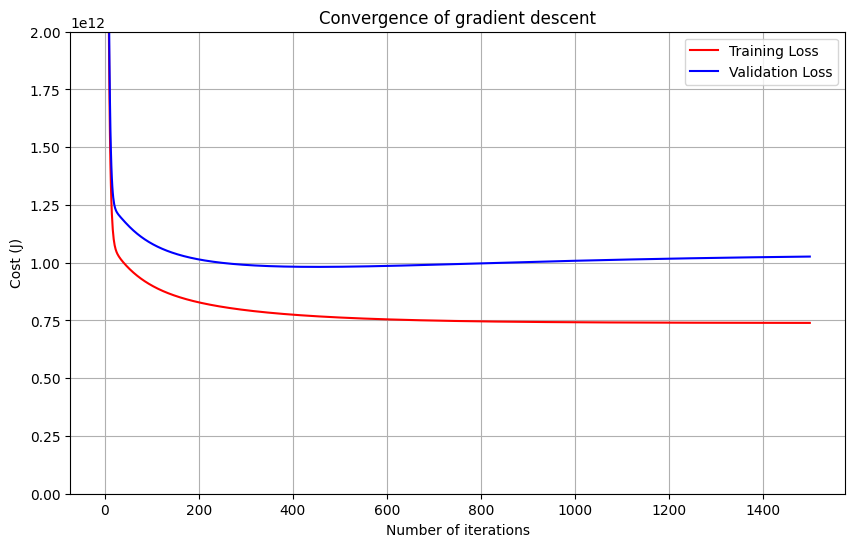

In [1066]:
# Area, bedrooms, bathrooms, stories, parking - Input normalization
alpha = 0.1

theta = (np.zeros(6))
X_train = np.hstack((
    X_0_train,
    X_n_train['area'],
    X_n_train['bedrooms'],
    X_n_train['bathrooms'],
    X_n_train['stories'],
    X_n_train['parking']
))
X_val = np.hstack((
    X_0_val,
    X_n_val['area'],
    X_n_val['bedrooms'],
    X_n_val['bathrooms'],
    X_n_val['stories'],
    X_n_val['parking']
))

theta, training_costs, validation_costs = gradient_descent(X_train, y_train, X_val, y_val, theta, alpha, iterations)
print('theta =', theta)
print('training loss history =', training_costs)
print('validation loss history =', validation_costs)

convergence_plot(training_costs, validation_costs)

theta = [1682263.25767739 3139826.6437666   976325.49569747 2605346.55809166
 1509064.63694715  444000.62730408  375412.37919166  426930.8693456
 1144717.80301962  958051.07384448  922118.02373827  557277.18881669]
training loss history = [7.72167059e+12 4.75396237e+12 3.08070046e+12 ... 5.38845953e+11
 5.38844115e+11 5.38842284e+11]
validation loss history = [8.05034279e+12 4.95707730e+12 3.22853914e+12 ... 8.28624245e+11
 8.28641475e+11 8.28658681e+11]


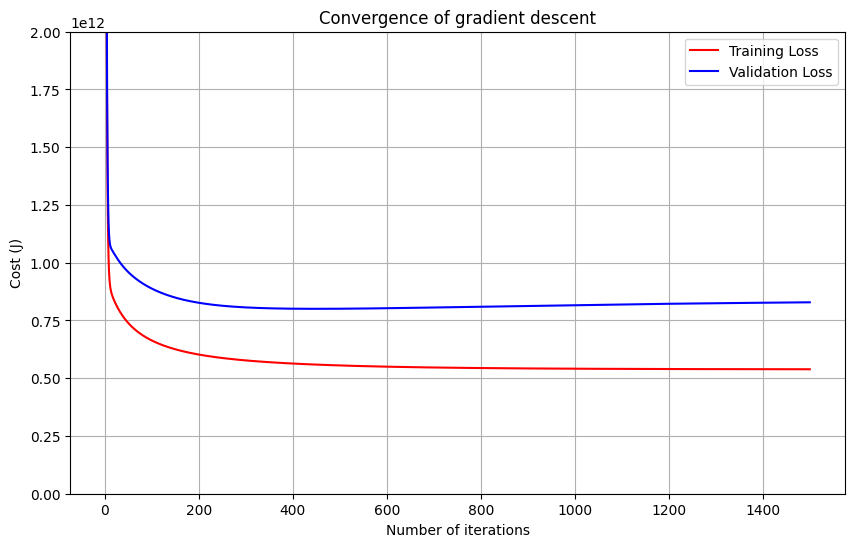

In [1067]:
# All except furnishing - Input normalization
alpha = 0.1

theta = (np.zeros(12))
X_train = np.hstack((
    X_0_train,
    X_n_train['area'],
    X_n_train['bedrooms'],
    X_n_train['bathrooms'],
    X_n_train['stories'],
    X_n_train['mainroad'],
    X_n_train['guestroom'],
    X_n_train['basement'],
    X_n_train['hotwaterheating'],
    X_n_train['airconditioning'],
    X_n_train['parking'],
    X_n_train['prefarea']
))
X_val = np.hstack((
    X_0_val,
    X_n_val['area'],
    X_n_val['bedrooms'],
    X_n_val['bathrooms'],
    X_n_val['stories'],
    X_n_val['mainroad'],
    X_n_val['guestroom'],
    X_n_val['basement'],
    X_n_val['hotwaterheating'],
    X_n_val['airconditioning'],
    X_n_val['parking'],
    X_n_val['prefarea']
))

theta, training_costs, validation_costs = gradient_descent(X_train, y_train, X_val, y_val, theta, alpha, iterations)
print('theta =', theta)
print('training loss history =', training_costs)
print('validation loss history =', validation_costs)

convergence_plot(training_costs, validation_costs)

In [1068]:
def input_standardize(x):
  return (x - np.mean(x)) / np.std(x)

In [1069]:
X_n_train = {name: input_standardize(x).reshape(m, 1) for name, x in zip(names, X_raw_train)}
X_n_val   = {name: input_standardize(x).reshape(n, 1) for name, x in zip(names, X_raw_val)}

theta = [4746955.27522935  687044.38072367  192882.76704052  521120.44874204
  506247.7855629   331210.49845596]
training loss history = [1.05197850e+13 8.56979212e+12 7.02300796e+12 ... 7.38968731e+11
 7.38968731e+11 7.38968731e+11]
validation loss history = [1.10817688e+13 9.10472811e+12 7.53037909e+12 ... 8.80672617e+11
 8.80672617e+11 8.80672617e+11]


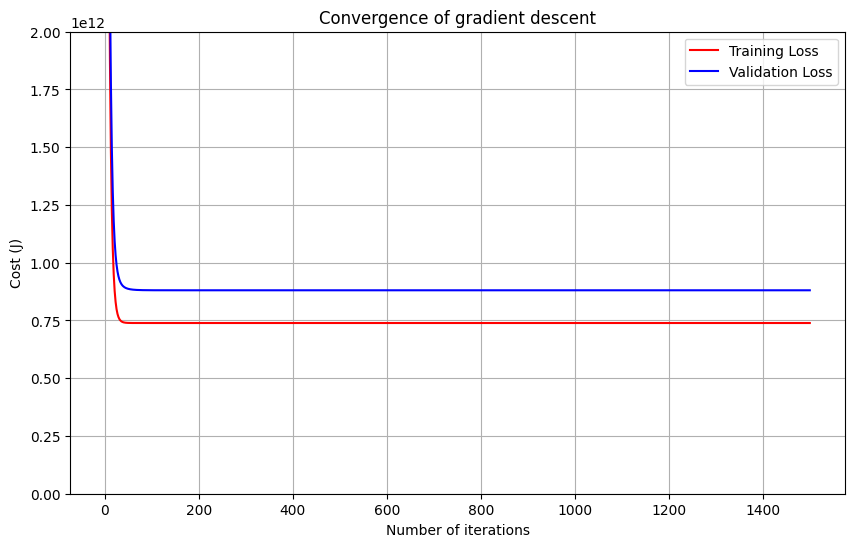

In [1070]:
# Area, bedrooms, bathrooms, stories, parking - Input standardization
alpha = 0.1

theta = (np.zeros(6))
X_train = np.hstack((
    X_0_train,
    X_n_train['area'],
    X_n_train['bedrooms'],
    X_n_train['bathrooms'],
    X_n_train['stories'],
    X_n_train['parking']
))
X_val = np.hstack((
    X_0_val,
    X_n_val['area'],
    X_n_val['bedrooms'],
    X_n_val['bathrooms'],
    X_n_val['stories'],
    X_n_val['parking']
))

theta, training_costs, validation_costs = gradient_descent(X_train, y_train, X_val, y_val, theta, alpha, iterations)
print('theta =', theta)
print('training loss history =', training_costs)
print('validation loss history =', validation_costs)

convergence_plot(training_costs, validation_costs)

theta = [4746955.27522935  512087.64829278  119262.36578653  449166.35627765
  451675.97827536  147459.5729254   140225.44703071  208647.39991216
  222122.97570746  436246.59736311  251748.10644106  229940.77955975]
training loss history = [1.03646282e+13 8.34899718e+12 6.78006230e+12 ... 5.38243357e+11
 5.38243357e+11 5.38243357e+11]
validation loss history = [1.09412866e+13 8.90196342e+12 7.30380929e+12 ... 7.17245203e+11
 7.17245203e+11 7.17245203e+11]


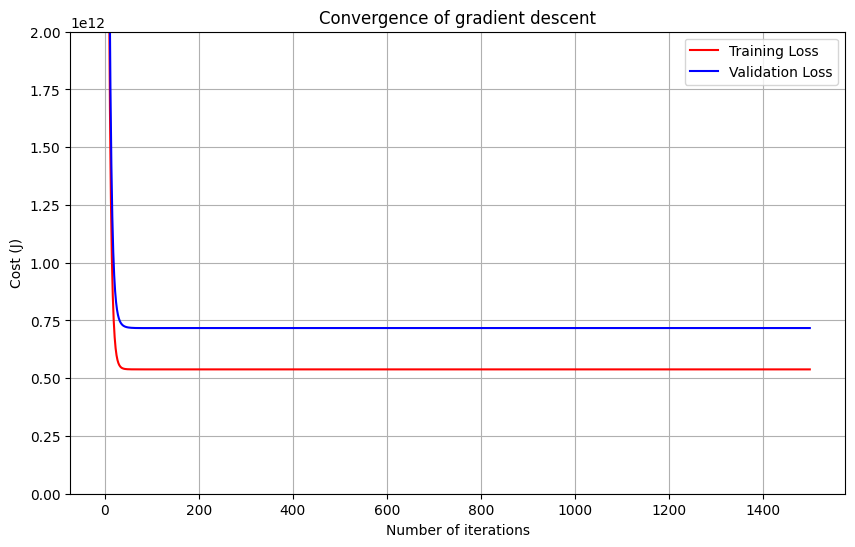

In [1071]:
# All except furnishing - Input standardization
alpha = 0.1

theta = (np.zeros(12))
X_train = np.hstack((
    X_0_train,
    X_n_train['area'],
    X_n_train['bedrooms'],
    X_n_train['bathrooms'],
    X_n_train['stories'],
    X_n_train['mainroad'],
    X_n_train['guestroom'],
    X_n_train['basement'],
    X_n_train['hotwaterheating'],
    X_n_train['airconditioning'],
    X_n_train['parking'],
    X_n_train['prefarea']
))
X_val = np.hstack((
    X_0_val,
    X_n_val['area'],
    X_n_val['bedrooms'],
    X_n_val['bathrooms'],
    X_n_val['stories'],
    X_n_val['mainroad'],
    X_n_val['guestroom'],
    X_n_val['basement'],
    X_n_val['hotwaterheating'],
    X_n_val['airconditioning'],
    X_n_val['parking'],
    X_n_val['prefarea']
))

theta, training_costs, validation_costs = gradient_descent(X_train, y_train, X_val, y_val, theta, alpha, iterations)
print('theta =', theta)
print('training loss history =', training_costs)
print('validation loss history =', validation_costs)

convergence_plot(training_costs, validation_costs)

In [1072]:
def compute_cost(X, y, theta, lambda_):

  m = len(y)

  errors = X.dot(theta) - y
  reg = lambda_ / (2 * m) * np.sum(theta[1:] ** 2)
  J = 1 / (2 * m) * np.sum(errors ** 2) + reg

  return J

In [1073]:
def gradient_descent(X_train, y_train, X_val, y_val, theta, alpha, iterations, lambda_):

  m = len(y_train)
  training_costs = np.zeros(iterations)
  validation_costs = np.zeros(iterations)

  for i in range(iterations):
    errors = X_train.dot(theta) - y_train
    penalty = lambda_ * theta
    penalty[0] = 0
    sum_delta = (alpha / m) * (X_train.transpose().dot(errors) + penalty)
    theta = theta - sum_delta
    training_costs[i] = compute_cost(X_train, y_train, theta, lambda_)
    validation_costs[i] = compute_cost(X_val, y_val, theta, 0)

  return theta, training_costs, validation_costs

theta = [4746955.27522935  624664.55212306  211436.90683318  484799.60217735
  462904.69200671  323823.38687031]
training loss history = [1.05218699e+13 8.57927611e+12 7.04121231e+12 ... 7.99988913e+11
 7.99988913e+11 7.99988913e+11]
validation loss history = [1.10817688e+13 9.10723825e+12 7.53565838e+12 ... 8.92546039e+11
 8.92546039e+11 8.92546039e+11]


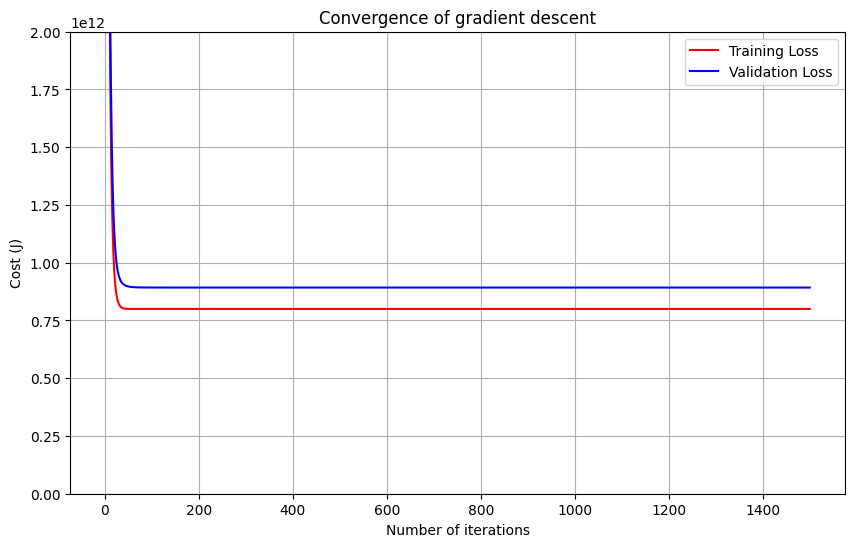

In [1074]:
# Area, bedrooms, bathrooms, stories, parking - Input standardization and parameters penalty
alpha = 0.1
lambda_ = 50

theta = (np.zeros(6))
X_train = np.hstack((
    X_0_train,
    X_n_train['area'],
    X_n_train['bedrooms'],
    X_n_train['bathrooms'],
    X_n_train['stories'],
    X_n_train['parking']
))
X_val = np.hstack((
    X_0_val,
    X_n_val['area'],
    X_n_val['bedrooms'],
    X_n_val['bathrooms'],
    X_n_val['stories'],
    X_n_val['parking']
))

theta, training_costs, validation_costs = gradient_descent(X_train, y_train, X_val, y_val, theta, alpha, iterations, lambda_)
print('theta =', theta)
print('training loss history =', training_costs)
print('validation loss history =', validation_costs)

convergence_plot(training_costs, validation_costs)

theta = [4746955.27522935  468762.67413885  147961.53158595  421315.83993364
  407795.71752945  157585.66435588  144329.55384032  183123.82984686
  196235.67794939  411434.00858217  249834.60614958  218726.25730379]
training loss history = [1.03677790e+13 8.36232859e+12 6.80404619e+12 ... 5.98396761e+11
 5.98396761e+11 5.98396761e+11]
validation loss history = [1.09412866e+13 8.90541117e+12 7.31055966e+12 ... 7.21566698e+11
 7.21566698e+11 7.21566698e+11]


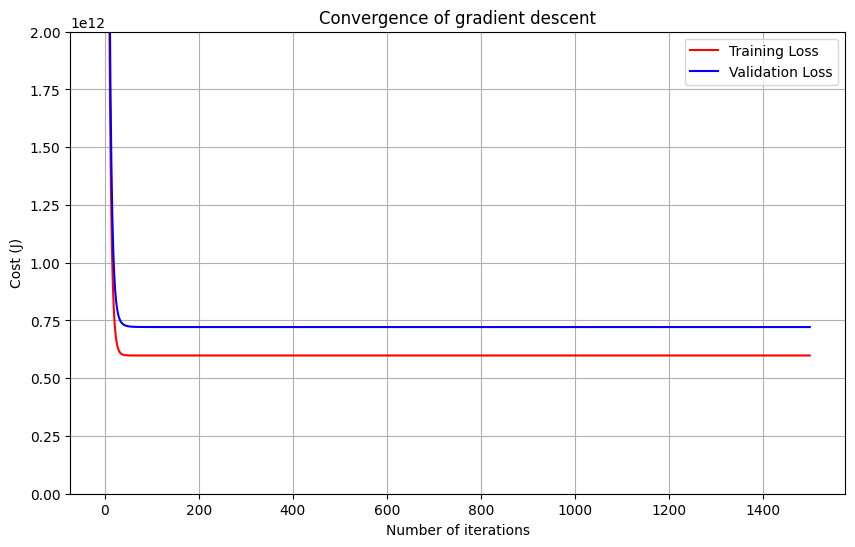

In [1075]:
# All except furnishing - Input standardization and parameters penalty
alpha = 0.1
lambda_ = 50

theta = (np.zeros(12))
X_train = np.hstack((
    X_0_train,
    X_n_train['area'],
    X_n_train['bedrooms'],
    X_n_train['bathrooms'],
    X_n_train['stories'],
    X_n_train['mainroad'],
    X_n_train['guestroom'],
    X_n_train['basement'],
    X_n_train['hotwaterheating'],
    X_n_train['airconditioning'],
    X_n_train['parking'],
    X_n_train['prefarea']
))
X_val = np.hstack((
    X_0_val,
    X_n_val['area'],
    X_n_val['bedrooms'],
    X_n_val['bathrooms'],
    X_n_val['stories'],
    X_n_val['mainroad'],
    X_n_val['guestroom'],
    X_n_val['basement'],
    X_n_val['hotwaterheating'],
    X_n_val['airconditioning'],
    X_n_val['parking'],
    X_n_val['prefarea']
))

theta, training_costs, validation_costs = gradient_descent(X_train, y_train, X_val, y_val, theta, alpha, iterations, lambda_)
print('theta =', theta)
print('training loss history =', training_costs)
print('validation loss history =', validation_costs)

convergence_plot(training_costs, validation_costs)